# Clustering - K-Means

## What is K-Means?

**K-Means** is an unsupervised algorithm that groups data into **k clusters** based on similarity.

**How it works:**
1. Randomly place k centroids in the data space.
2. Assign each point to the nearest centroid.
3. Move each centroid to the mean of its assigned points.
4. Repeat steps 2–3 until centroids stop moving.

**Key assumptions:**
- Clusters are roughly spherical and similarly sized.
- You need to specify k in advance.

**Why use it?** It's fast, simple, and works well when clusters are compact and well-separated.

### Step 1 — Generate synthetic data

We create a dataset with 3 well-separated blob clusters using `make_blobs`. This is a controlled dataset ideal for demonstrating clustering algorithms.

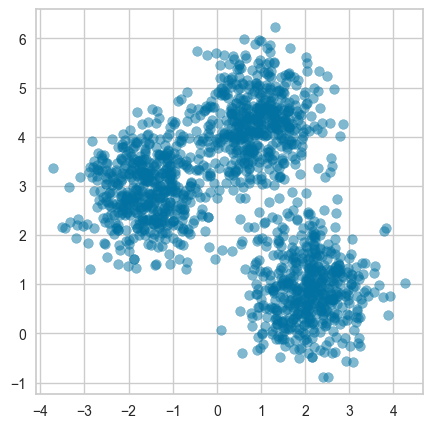

In [20]:
# K-means
import numpy as np
import matplotlib.pyplot as plt

from sklearn import cluster, datasets
from sklearn.preprocessing import StandardScaler
from matplotlib.lines import Line2D


n_samples = 1500
X, y = datasets.make_blobs(n_samples=n_samples, centers=3, cluster_std=0.7, n_features=2, random_state=0)

plt.figure(figsize=(5, 5))
plt.scatter(X[:, 0], X[:, 1],alpha=0.5,)
plt.show()

In [21]:
# plt.style.use('classic')

### Step 2 — Fit K-Means with k=3

We tell the algorithm to find 3 clusters — matching the true number of blobs in our data. K-Means assigns a color (cluster label) to each point based on which centroid is closest.

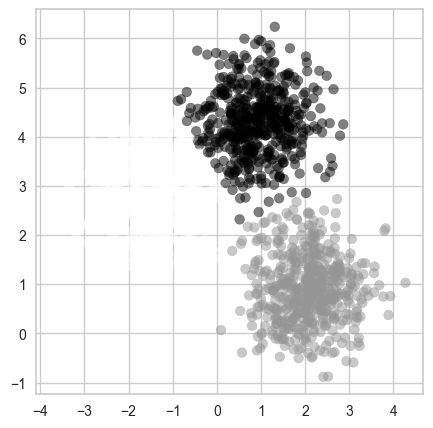

In [22]:
kmeans = cluster.KMeans(n_clusters=3)
kmeans.fit(X)
pred = kmeans.predict(X)

plt.figure(figsize=(5, 5))
plt.scatter(X[:, 0], X[:, 1], c=pred,alpha=0.5)
plt.show()

### Step 3 — Effect of choosing the wrong k

What happens if we pick the wrong number of clusters? 

Below we try k=2 (too few) and k=4 (too many). 

The algorithm will still produce a result — it just won't reflect the real structure of the data.

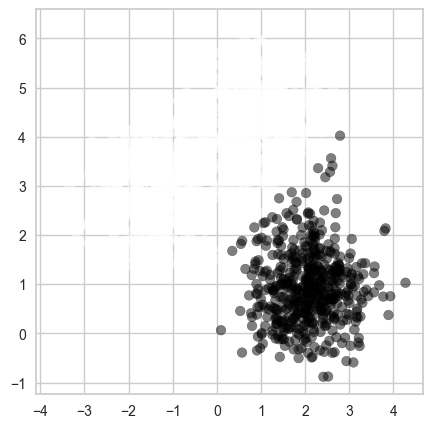

In [23]:
kmeans = cluster.KMeans(n_clusters=2)
kmeans.fit(X)
pred = kmeans.predict(X)

plt.figure(figsize=(5, 5))
plt.scatter(X[:, 0], X[:, 1], c=pred,alpha=0.5)
plt.show()

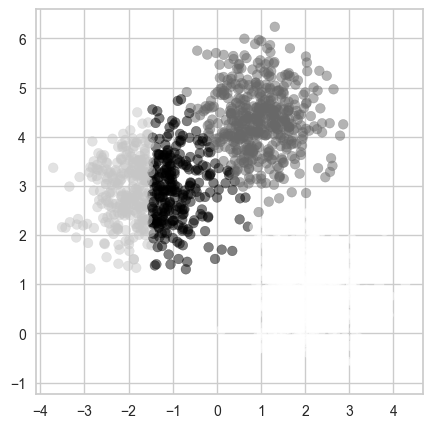

In [24]:
kmeans = cluster.KMeans(n_clusters=4)
kmeans.fit(X)
pred = kmeans.predict(X)

plt.figure(figsize=(5, 5))
plt.scatter(X[:, 0], X[:, 1], c=pred,alpha=0.5)
plt.show()

# Agglomerative clustering

## What is Agglomerative Clustering?

Agglomerative clustering is another type of clustering algorithm.

It starts by treating each data point as its own cluster and then repeatedly merges the closest clusters together. This creates a hierarchy of clusters, whereas K-means directly groups data into a fixed number of clusters.


**Agglomerative clustering** is a **hierarchical** clustering method. It takes a bottom-up approach:
1. Start with each point as its own cluster.
2. Repeatedly merge the two closest clusters.
3. Continue until all points are in one cluster (or until k clusters remain).

The key parameter is **linkage**, which defines how "distance between clusters" is measured:
- **Ward**: minimizes the increase in total variance when merging — tends to produce compact, equally sized clusters.
- **Complete**: uses the maximum distance between any two points in different clusters — penalizes outliers.
- **Single**: uses the minimum distance between any two points — can chain clusters along thin paths.


**Why use it?** 
- Unlike K-means, agglomerative clustering does not depend on initial cluster centers. Instead, it builds clusters step by step by merging the most similar groups, which can help reveal the natural structure of the data.
- For example, it capture non-spherical shapes depending on the linkage

In [25]:
from sklearn import cluster

### Ward linkage

Ward merges clusters that cause the smallest increase in within-cluster variance. This tends to produce well-balanced, compact clusters — it's a safe default for most use cases.

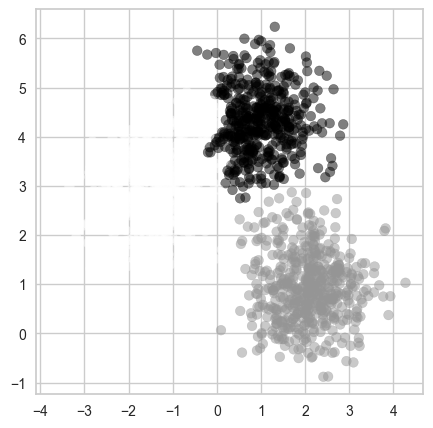

In [26]:
# ward linkage tends to produce relatively equally sized clusters
agglomerative = cluster.AgglomerativeClustering(n_clusters=3,linkage='ward')
pred = agglomerative.fit_predict(X)

plt.figure(figsize=(5, 5))
plt.scatter(X[:, 0], X[:, 1], c=pred,alpha=0.5)
plt.show()

### Complete linkage

Complete linkage measures the distance between two clusters as the **maximum** distance between any pair of points across the clusters. It creates compact clusters but is sensitive to outliers.

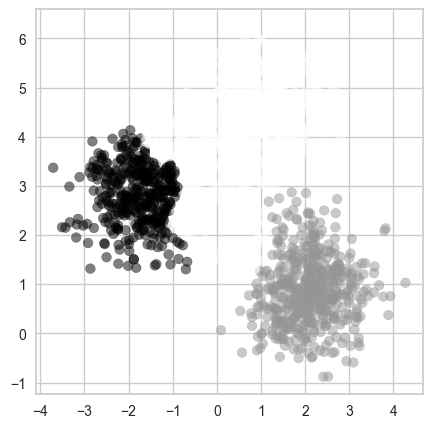

In [27]:
# complete linkage penalizes heavily outliers
agglomerative = cluster.AgglomerativeClustering(n_clusters=3,linkage='complete')
pred = agglomerative.fit_predict(X)

plt.figure(figsize=(5, 5))
plt.scatter(X[:, 0], X[:, 1], c=pred,alpha=0.5)
plt.show()

### Single linkage

Single linkage measures the distance between clusters as the **minimum** distance between any pair of points. This can lead to "chaining" — clusters that stretch along thin connections rather than forming compact blobs. Generally performs poorly on blob-shaped data, but excels on elongated or irregular shapes.

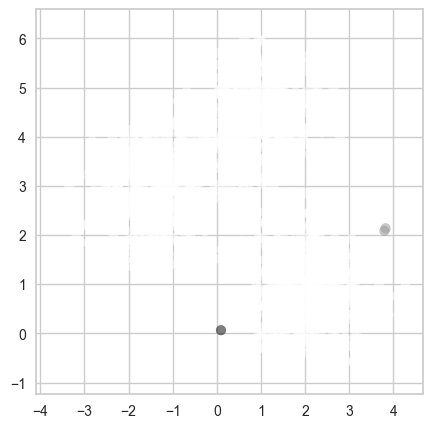

In [28]:
# different algorithms are good for different applications
# single (or minimum) linkage just finds the clusters that have the least distance between any 2 points. This means the algorithm is bad at "jumping" from one cluster to another
agglomerative = cluster.AgglomerativeClustering(n_clusters=3,linkage='single')
pred = agglomerative.fit_predict(X)

plt.figure(figsize=(5, 5))
plt.scatter(X[:, 0], X[:, 1], c=pred,alpha=0.5)
plt.show()

<br>

### Comparing K-Means vs. Single linkage on non-convex data

Blob-shaped data favors K-Means and Ward. But what about data shaped like **two crescent moons**? This test shows that algorithm choice matters — single linkage can follow the curved shape of the data, while K-Means cannot.

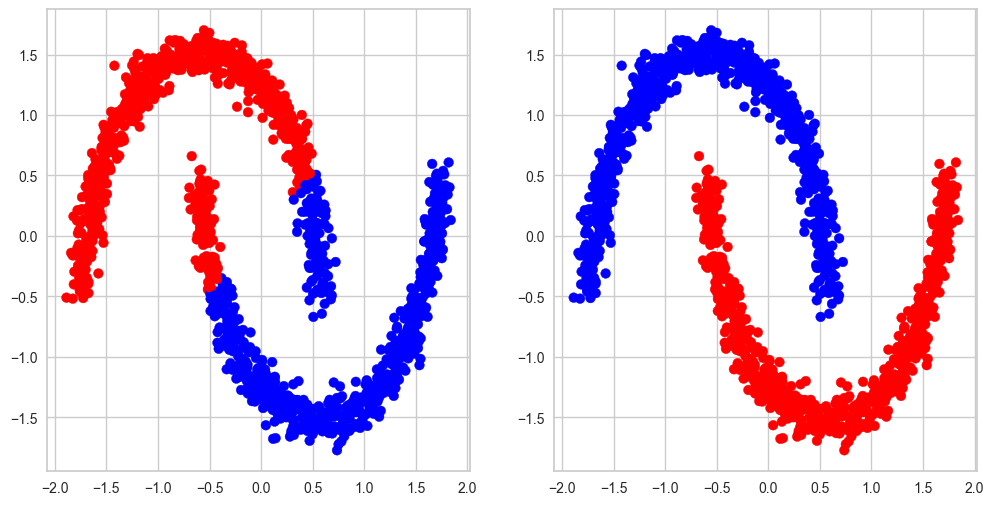

In [30]:
# different algorithms are good for different applications

n_samples = 1500
X, y = datasets.make_moons(n_samples=n_samples, noise=.05)
X = StandardScaler().fit_transform(X)

kmeans = cluster.KMeans(n_clusters=2)
kmeans.fit(X)
y1_pred = kmeans.predict(X)


single = cluster.AgglomerativeClustering(n_clusters=2, linkage='single')
y2_pred = single.fit_predict(X)


options, charts = plt.subplots(1, 2, figsize=(12, 6))
colors = np.array(['blue', 'red'])
charts[0].scatter(X[:, 0], X[:, 1], color=colors[y1_pred])
charts[1].scatter(X[:, 0], X[:, 1], color=colors[y2_pred])
plt.show()

# Clustering metrics

## Silhouette Score

Since clustering is unsupervised (no labels), we need a way to evaluate quality without ground truth. The **silhouette score** measures how well each point fits its own cluster compared to neighboring clusters.

- **Score = 1**: point is well inside its cluster and far from others — perfect.
- **Score = 0**: point is near the boundary between two clusters.
- **Score = -1**: point likely belongs to the wrong cluster.

A higher average silhouette score indicates more distinct, well-separated clusters. However, it works best when clusters are convex (blob-shaped) — it can mislead on complex shapes.

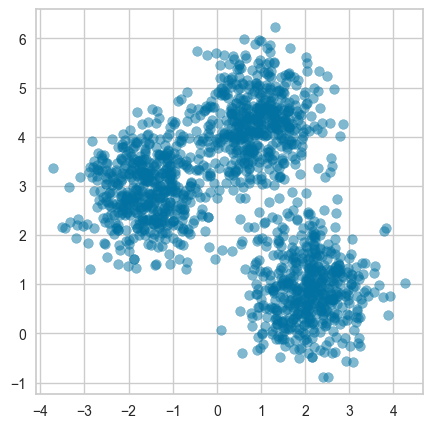

In [39]:
n_samples = 1500
X, y = datasets.make_blobs(n_samples=n_samples, centers=3, cluster_std=0.7, n_features=2, random_state=0)


plt.figure(figsize=(5, 5))
plt.scatter(X[:, 0], X[:, 1],alpha=0.5,)
plt.show()

In [48]:
# plt.style.use('classic')

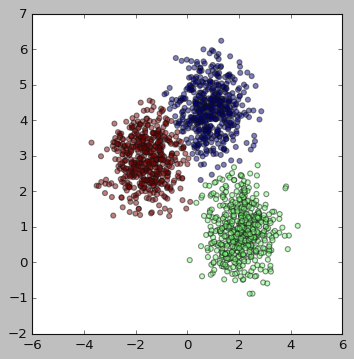

Model 1 Silhouette Score: 0.6056399066187851


In [49]:
# silhouette score is somewhat of a technical measue. I behaves well with intuitive undertandings of clusters as "blobs"


from sklearn.metrics import silhouette_score

kmeans = cluster.KMeans(n_clusters=3)
kmeans.fit(X)
pred = kmeans.predict(X)

plt.figure(figsize=(5, 5))
plt.scatter(X[:, 0], X[:, 1], c=pred,alpha=0.5)
plt.show()
print("Model 1 Silhouette Score: {}".format(silhouette_score(X, pred, metric='euclidean')))

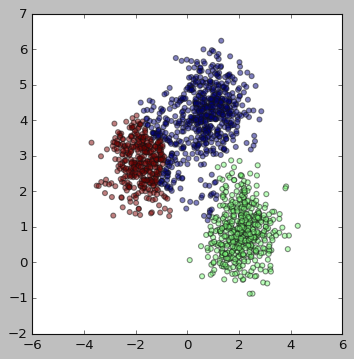

Model 2 Silhouette Score: 0.528140155059521


In [50]:
agglomerative = cluster.AgglomerativeClustering(n_clusters=3,linkage='complete')
pred = agglomerative.fit_predict(X)

plt.figure(figsize=(5, 5))
plt.scatter(X[:, 0], X[:, 1], c=pred,alpha=0.5)
plt.show()
print("Model 2 Silhouette Score: {}".format(silhouette_score(X, pred, metric='euclidean')))

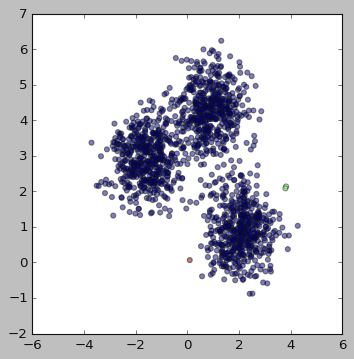

Model 2 Silhouette Score: -0.0072286779275968285


In [51]:
agglomerative = cluster.AgglomerativeClustering(n_clusters=3,linkage='single')
pred = agglomerative.fit_predict(X)

plt.figure(figsize=(5, 5))
plt.scatter(X[:, 0], X[:, 1], c=pred,alpha=0.5)
plt.show()
print("Model 2 Silhouette Score: {}".format(silhouette_score(X, pred, metric='euclidean')))

### Silhouette score on non-convex data

Now we apply the silhouette score to the moon-shaped dataset. Even though single linkage produces the visually correct clustering, its silhouette score may be lower than K-Means'. 

This is a key limitation: **a better silhouette score doesn't always mean a more meaningful clustering.** ⚠️

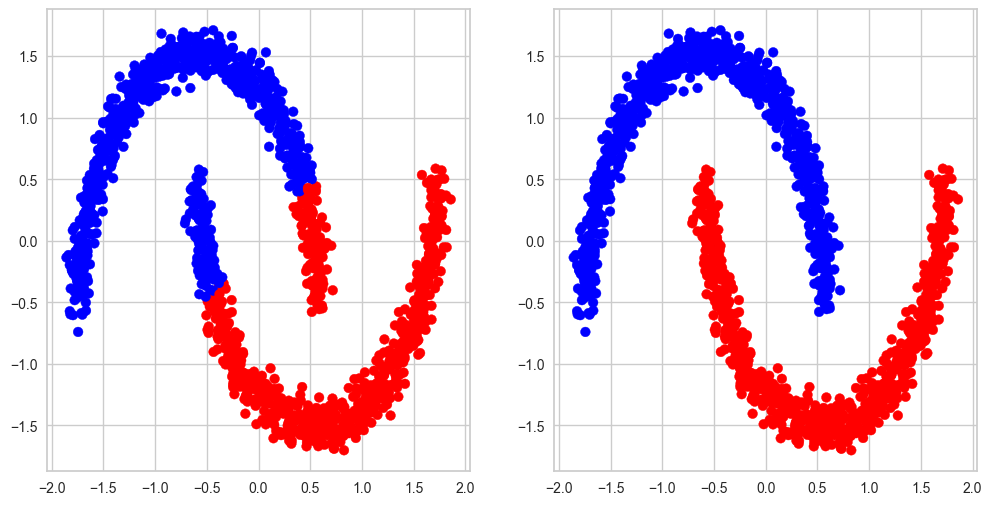

Model 1 Silhouette Score: 0.49589456393761966
Model 2 Silhouette Score: 0.3935725747103365


In [34]:
# but no so well when we start having "weird" cluster logics

n_samples = 1500
X, y = datasets.make_moons(n_samples=n_samples, noise=.05)
X = StandardScaler().fit_transform(X)

kmeans = cluster.KMeans(n_clusters=2)
kmeans.fit(X)
y1_pred = kmeans.predict(X)


single = cluster.AgglomerativeClustering(n_clusters=2, linkage='single')
y2_pred = single.fit_predict(X)


options, charts = plt.subplots(1, 2, figsize=(12, 6))
colors = np.array(['blue', 'red'])
charts[0].scatter(X[:, 0], X[:, 1], color=colors[y1_pred])
charts[1].scatter(X[:, 0], X[:, 1], color=colors[y2_pred])
plt.show()

print("Model 1 Silhouette Score: {}".format(silhouette_score(X, y1_pred)))
print("Model 2 Silhouette Score: {}".format(silhouette_score(X, y2_pred)))

<br>

# Number of clusters

## Choosing the number of clusters

One of the biggest challenges in clustering is: **how many clusters should we use?**

There's no single right answer — it depends on the data and the use case. However, there are tools to help guide the decision. 

We'll look at the **elbow method**, which plots a clustering quality metric (inertia or silhouette) for different values of k and looks for a "bend" in the curve — the point where adding more clusters stops improving the result significantly.

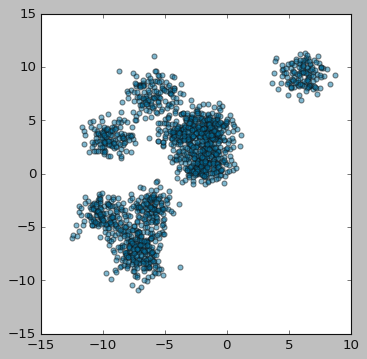

In [52]:
from sklearn import cluster, datasets

n_samples = 1500
X, y = datasets.make_blobs(n_samples=n_samples, centers=12, cluster_std=1, n_features=2, random_state=1)
plt.figure(figsize=(5, 5))
plt.scatter(X[:, 0], X[:, 1],alpha=0.5)
plt.show()
#even though data was generated with 12 centers, 5 clusters could make sense, even 7 or 8

### The elbow method

`KElbowVisualizer` from the `yellowbrick` library fits K-Means for a range of k values and plots the distortion score (inertia) vs. k. The "elbow" — the point where the curve bends — suggests a good balance between number of clusters and fit quality.

Note: the data was generated with 12 centers, but visually a smaller number (e.g. 5–8) may make more practical sense.

In [36]:
# !pip install yellowbrick

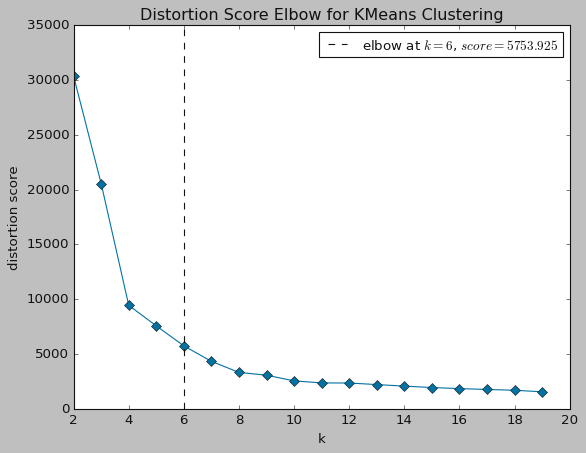

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [54]:
# two elbows here are interesting to consider

from yellowbrick.cluster import KElbowVisualizer

model = cluster.KMeans()
visualizer = KElbowVisualizer(model, k=(2,20), timings=False)
visualizer.fit(X)
visualizer.poof()


### Overfitting with too many clusters

More clusters always reduces inertia — in the extreme, every point could be its own cluster with zero error. 

This cell illustrates that extreme: when k approaches n (number of data points), the score is perfect but completely useless. **A good metric score is not the same as a useful model.** ⚠️

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/yellowbrick/utils/kneed.py:156: YellowbrickWarning: No 'knee' or 'elbow point' detected This could be due to bad clustering, no actual clusters being formed etc.
  warnings.warn(warning_message, YellowbrickWarning)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/yellowbrick/cluster/elbow.py:374: YellowbrickWarning: No 'knee' or 'elbow' point detected, pass `locate_elbow=False` to remove the warning
  warnings.warn(warning_message, YellowbrickWarning)


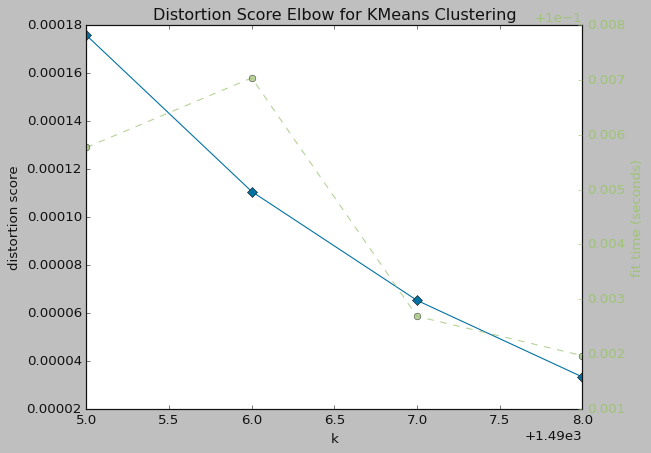

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [70]:
#best score =!= most useful score
from yellowbrick.cluster import KElbowVisualizer

model = cluster.KMeans()
# visualizer = KElbowVisualizer(model, k=(1000,1010))
visualizer = KElbowVisualizer(model, k=(1495,1499))
visualizer.fit(X)
visualizer.poof()